In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df_video = pd.read_csv(r"D:\tn-da22tta-110122034-chaugiabao-youtube-dw-trending\src\analysis\data\cleaned_video.csv")
pd.set_option('display.max_columns', None)
print(f"Data shape before: {df_video.shape}")

Data shape before: (1171067, 45)


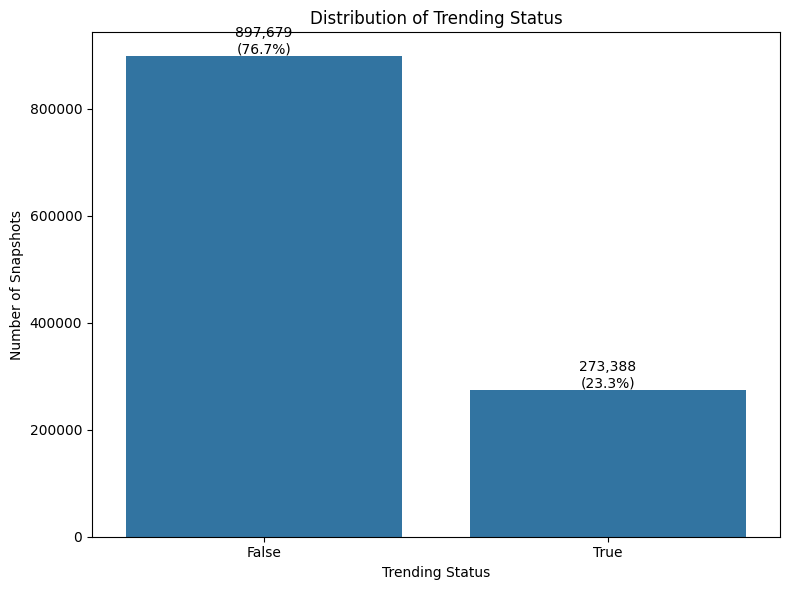

In [2]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=df_video,
    x='is_trending'
)

total = len(df_video)

for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100

    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Distribution of Trending Status")
plt.xlabel("Trending Status")
plt.ylabel("Number of Snapshots")

plt.tight_layout()
plt.show()

In [3]:
# Thống kê cơ bản
print("=== SUBSCRIBER_COUNT ===")
print(df_video['subscriber_count'].describe())
print(f"Missing: {df_video['subscriber_count'].isna().sum()}")
print(f"Zeros: {(df_video['subscriber_count'] == 0).sum()}")

# So sánh trending vs non-trending
print("\n--- By Trending Status ---")
print(df_video.groupby('is_trending')['subscriber_count'].describe())

=== SUBSCRIBER_COUNT ===
count    1.171067e+06
mean     2.094982e+06
std      1.019262e+07
min      0.000000e+00
25%      4.580000e+03
50%      9.780000e+04
75%      9.080000e+05
max      4.900000e+08
Name: subscriber_count, dtype: float64
Missing: 0
Zeros: 2471

--- By Trending Status ---
                count          mean           std  min      25%       50%  \
is_trending                                                                 
False        897679.0  2.288074e+06  1.104706e+07  0.0   2150.0   63400.0   
True         273388.0  1.460956e+06  6.616335e+06  0.0  41600.0  224000.0   

                  75%          max  
is_trending                         
False        882000.0  490000000.0  
True         979000.0  312000000.0  


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24056\3660722630.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_video, x='is_trending', y=np.log10(df_video['subscriber_count'] + 1),
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24056\3660722630.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Trending', 'Trending'])


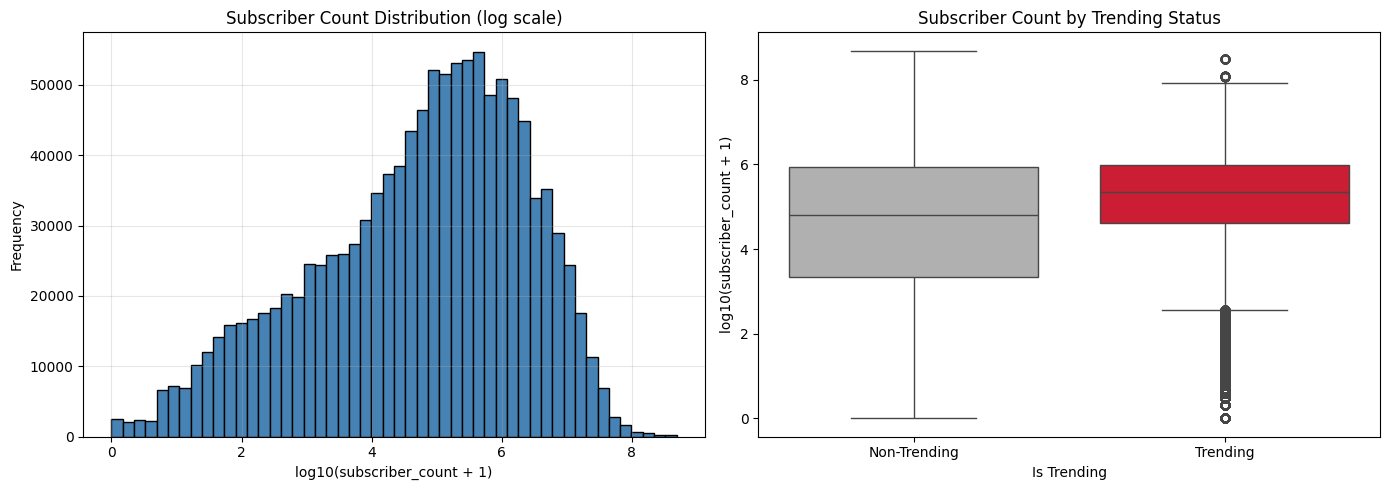

In [4]:
# Distribution plot - log scale (vì right-skewed)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(np.log10(df_video['subscriber_count'] + 1), bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('log10(subscriber_count + 1)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Subscriber Count Distribution (log scale)')
axes[0].grid(alpha=0.3)

# Boxplot by trending
sns.boxplot(data=df_video, x='is_trending', y=np.log10(df_video['subscriber_count'] + 1), 
            ax=axes[1], palette=['#B0B0B0', '#E8001D'])
axes[1].set_xlabel('Is Trending')
axes[1].set_ylabel('log10(subscriber_count + 1)')
axes[1].set_title('Subscriber Count by Trending Status')
axes[1].set_xticklabels(['Non-Trending', 'Trending'])

plt.tight_layout()
plt.show()

In [5]:
# Thống kê cơ bản
print("=== VIEW_COUNT ===")
print(df_video['view_count'].describe())
print(f"Missing: {df_video['view_count'].isna().sum()}")
print(f"Zeros: {(df_video['view_count'] == 0).sum()}")

# So sánh trending vs non-trending
print("\n--- By Trending Status ---")
print(df_video.groupby('is_trending')['view_count'].describe())

=== VIEW_COUNT ===
count    1.171067e+06
mean     1.200362e+09
std      7.487281e+09
min      0.000000e+00
25%      1.780027e+06
50%      3.756817e+07
75%      3.525118e+08
max      3.422487e+11
Name: view_count, dtype: float64
Missing: 0
Zeros: 866

--- By Trending Status ---
                count          mean           std  min         25%  \
is_trending                                                          
False        897679.0  1.328826e+09  7.862597e+09  0.0    859389.0   
True         273388.0  7.785438e+08  6.075426e+09  0.0  13653579.0   

                    50%          75%           max  
is_trending                                         
False        24848593.0  331025523.0  3.422487e+11  
True         89631175.0  409846775.0  3.422487e+11  


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24056\204267576.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_video, x='is_trending', y=np.log10(df_video['view_count'] + 1),
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24056\204267576.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Trending', 'Trending'])


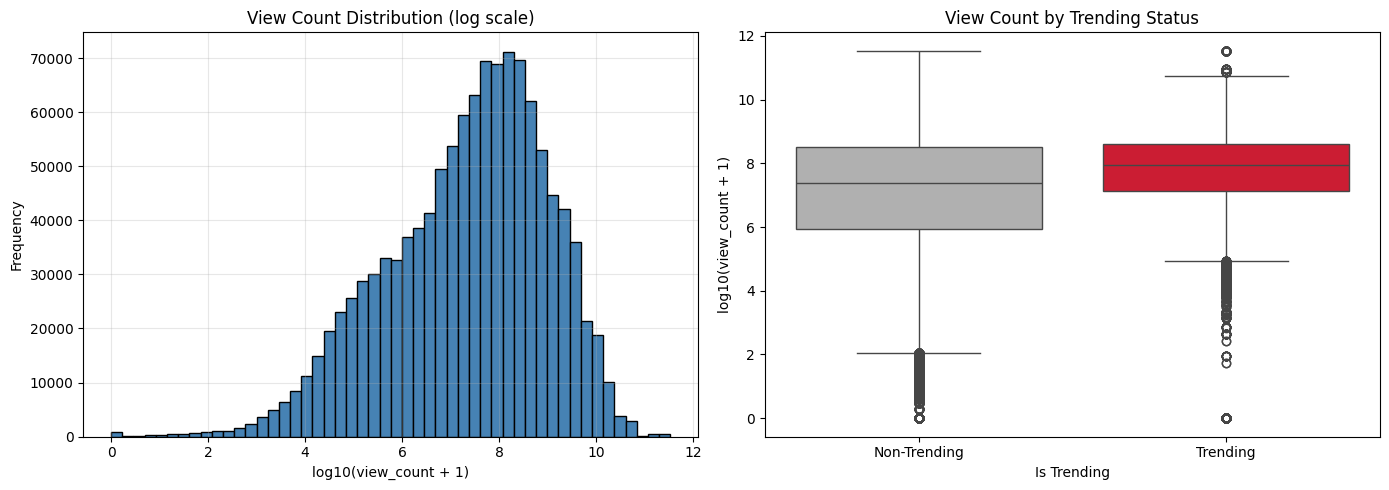

In [6]:
# Distribution plot - log scale
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(np.log10(df_video['view_count'] + 1), bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('log10(view_count + 1)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('View Count Distribution (log scale)')
axes[0].grid(alpha=0.3)

# Boxplot by trending
sns.boxplot(data=df_video, x='is_trending', y=np.log10(df_video['view_count'] + 1), 
            ax=axes[1], palette=['#B0B0B0', '#E8001D'])
axes[1].set_xlabel('Is Trending')
axes[1].set_ylabel('log10(view_count + 1)')
axes[1].set_title('View Count by Trending Status')
axes[1].set_xticklabels(['Non-Trending', 'Trending'])

plt.tight_layout()
plt.show()

In [23]:
# Thống kê cơ bản
print("=== VIDEO_COUNT ===")
print(df_video['video_count'].describe())
print(f"Missing: {df_video['video_count'].isna().sum()}")
print(f"Zeros: {(df_video['video_count'] == 0).sum()}")

# So sánh trending vs non-trending
print("\n--- By Trending Status ---")
print(df_video.groupby('is_trending')['video_count'].describe())

=== VIDEO_COUNT ===
count    1.171067e+06
mean     1.976125e+03
std      1.357685e+04
min      0.000000e+00
25%      1.130000e+02
50%      4.160000e+02
75%      1.274000e+03
max      6.631150e+05
Name: video_count, dtype: float64
Missing: 0
Zeros: 839

--- By Trending Status ---
                count         mean           std  min    25%    50%     75%  \
is_trending                                                                   
False        897679.0  2088.952964  14857.320107  0.0  109.0  378.0  1146.0   
True         273388.0  1605.649381   8037.502866  0.0  128.0  596.0  1766.0   

                  max  
is_trending            
False        663115.0  
True         590287.0  


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24056\3210751888.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_video, x='is_trending', y=np.log10(df_video['video_count'] + 1),
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24056\3210751888.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Trending', 'Trending'])


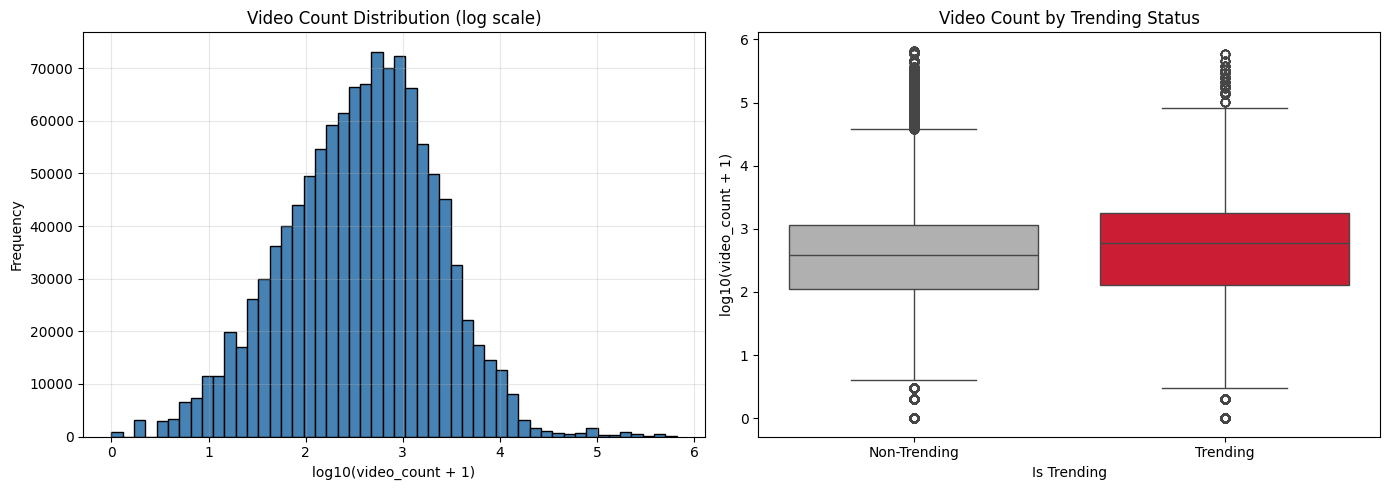

In [24]:
# Distribution plot - log scale
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(np.log10(df_video['video_count'] + 1), bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('log10(video_count + 1)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Video Count Distribution (log scale)')
axes[0].grid(alpha=0.3)

# Boxplot by trending
sns.boxplot(data=df_video, x='is_trending', y=np.log10(df_video['video_count'] + 1), 
            ax=axes[1], palette=['#B0B0B0', '#E8001D'])
axes[1].set_xlabel('Is Trending')
axes[1].set_ylabel('log10(video_count + 1)')
axes[1].set_title('Video Count by Trending Status')
axes[1].set_xticklabels(['Non-Trending', 'Trending'])

plt.tight_layout()
plt.show()

In [9]:
# Thống kê cơ bản
print("=== DURATION_SECONDS ===")
print(df_video['duration_seconds'].describe())
print(f"Missing: {df_video['duration_seconds'].isna().sum()}")
print(f"Zeros: {(df_video['duration_seconds'] == 0).sum()}")

# So sánh trending vs non-trending
print("\n--- By Trending Status ---")
print(df_video.groupby('is_trending')['duration_seconds'].describe())

=== DURATION_SECONDS ===
count    1.171067e+06
mean     1.565434e+03
std      5.729794e+03
min      0.000000e+00
25%      3.400000e+01
50%      1.610000e+02
75%      1.083000e+03
max      4.167040e+05
Name: duration_seconds, dtype: float64
Missing: 0
Zeros: 543

--- By Trending Status ---
                count         mean          std  min    25%     50%     75%  \
is_trending                                                                   
False        897679.0  1154.458087  5711.456090  0.0   26.0    60.0   621.0   
True         273388.0  2914.889604  5580.677422  2.0  321.0  1044.0  2208.0   

                  max  
is_trending            
False        416704.0  
True          59793.0  


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24056\3218534816.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_video, x='is_trending', y='duration_seconds',
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24056\3218534816.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Trending', 'Trending'])


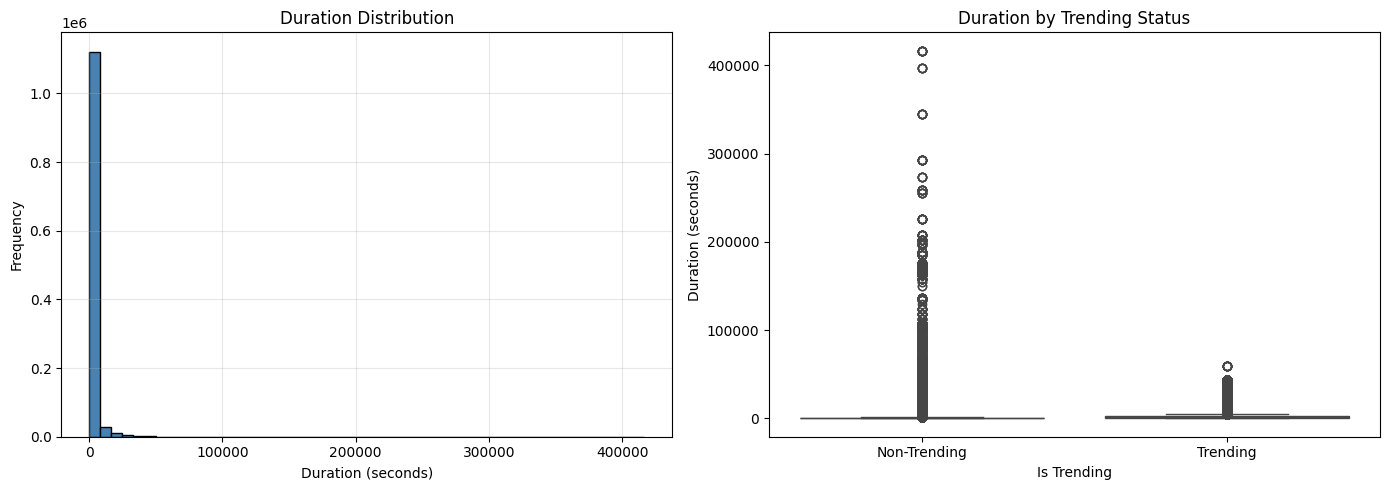

In [10]:
# Distribution plot - linear scale (không cần log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_video['duration_seconds'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Duration Distribution')
axes[0].grid(alpha=0.3)

# Boxplot by trending
sns.boxplot(data=df_video, x='is_trending', y='duration_seconds', 
            ax=axes[1], palette=['#B0B0B0', '#E8001D'])
axes[1].set_xlabel('Is Trending')
axes[1].set_ylabel('Duration (seconds)')
axes[1].set_title('Duration by Trending Status')
axes[1].set_xticklabels(['Non-Trending', 'Trending'])

plt.tight_layout()
plt.show()

In [11]:
# Thống kê cơ bản
print("=== LIKE_RATE ===")
print(df_video['like_rate'].describe())
print(f"Missing: {df_video['like_rate'].isna().sum()}")
print(f"Zeros: {(df_video['like_rate'] == 0).sum()}")
print(f"Min: {df_video['like_rate'].min()}, Max: {df_video['like_rate'].max()}")

# So sánh trending vs non-trending
print("\n--- By Trending Status ---")
print(df_video.groupby('is_trending')['like_rate'].describe())

=== LIKE_RATE ===
count    1.171067e+06
mean     2.741785e-02
std      3.830125e-02
min      0.000000e+00
25%      8.402883e-03
50%      1.816280e-02
75%      3.499836e-02
max      1.000000e+00
Name: like_rate, dtype: float64
Missing: 0
Zeros: 73775
Min: 0.0, Max: 1.0

--- By Trending Status ---
                count      mean       std  min       25%       50%       75%  \
is_trending                                                                    
False        897679.0  0.025138  0.039917  0.0  0.007726  0.016543  0.030942   
True         273388.0  0.034905  0.031286  0.0  0.011580  0.026225  0.049513   

                  max  
is_trending            
False        1.000000  
True         0.914831  


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24056\2519908720.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_video, x='is_trending', y='like_rate',
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24056\2519908720.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Trending', 'Trending'])


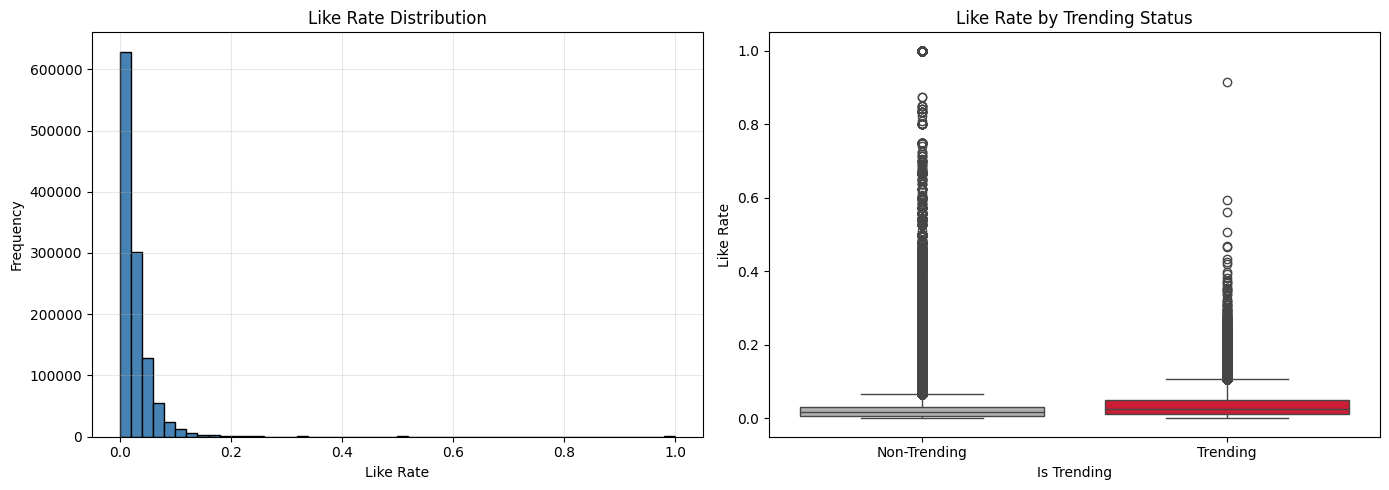

In [12]:
# Distribution plot - xóa NaN trước
like_rate_clean = df_video['like_rate'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(like_rate_clean, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Like Rate')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Like Rate Distribution')
axes[0].grid(alpha=0.3)

# Boxplot by trending
sns.boxplot(data=df_video, x='is_trending', y='like_rate', 
            ax=axes[1], palette=['#B0B0B0', '#E8001D'])
axes[1].set_xlabel('Is Trending')
axes[1].set_ylabel('Like Rate')
axes[1].set_title('Like Rate by Trending Status')
axes[1].set_xticklabels(['Non-Trending', 'Trending'])

plt.tight_layout()
plt.show()

In [13]:
# Thống kê cơ bản
print("=== COMMENT_RATE ===")
print(df_video['comment_rate'].describe())
print(f"Missing: {df_video['comment_rate'].isna().sum()}")
print(f"Zeros: {(df_video['comment_rate'] == 0).sum()}")
print(f"Min: {df_video['comment_rate'].min()}, Max: {df_video['comment_rate'].max()}")

# So sánh trending vs non-trending
print("\n--- By Trending Status ---")
print(df_video.groupby('is_trending')['comment_rate'].describe())

=== COMMENT_RATE ===
count    1.171067e+06
mean     2.434545e-03
std      2.123462e-02
min      0.000000e+00
25%      5.353009e-05
50%      3.830038e-04
75%      1.490313e-03
max      3.333333e+00
Name: comment_rate, dtype: float64
Missing: 0
Zeros: 215875
Min: 0.0, Max: 3.333333333333333

--- By Trending Status ---
                count      mean       std  min       25%       50%       75%  \
is_trending                                                                    
False        897679.0  0.002300  0.024054  0.0  0.000027  0.000262  0.000976   
True         273388.0  0.002876  0.005602  0.0  0.000315  0.001402  0.003417   

                  max  
is_trending            
False        3.333333  
True         0.379070  


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24056\2640050822.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_video, x='is_trending', y='comment_rate',
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24056\2640050822.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Trending', 'Trending'])


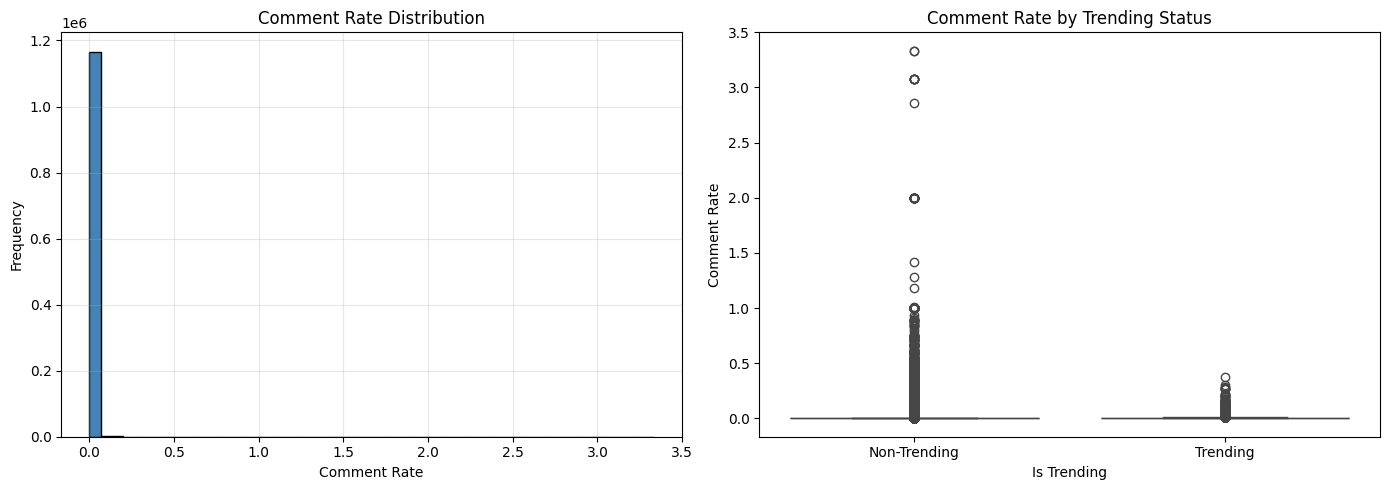

In [14]:
# Distribution plot - xóa NaN trước
comment_rate_clean = df_video['comment_rate'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(comment_rate_clean, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Comment Rate')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Comment Rate Distribution')
axes[0].grid(alpha=0.3)

# Boxplot by trending
sns.boxplot(data=df_video, x='is_trending', y='comment_rate', 
            ax=axes[1], palette=['#B0B0B0', '#E8001D'])
axes[1].set_xlabel('Is Trending')
axes[1].set_ylabel('Comment Rate')
axes[1].set_title('Comment Rate by Trending Status')
axes[1].set_xticklabels(['Non-Trending', 'Trending'])

plt.tight_layout()
plt.show()

In [15]:
# Thống kê cơ bản
print("=== TOPIC ===")
print(f"Unique topics: {df_video['topic'].nunique()}")
print(f"Missing: {df_video['topic'].isna().sum()}")
print("\nTop 10 topics:")
print(df_video['topic'].value_counts().head(10))

=== TOPIC ===
Unique topics: 25
Missing: 0

Top 10 topics:
topic
gaming           357332
music            180120
entertainment    152345
education         93016
vlog              64490
food              54775
fitness           49325
sports            43473
technology        30633
travel            25582
Name: count, dtype: int64


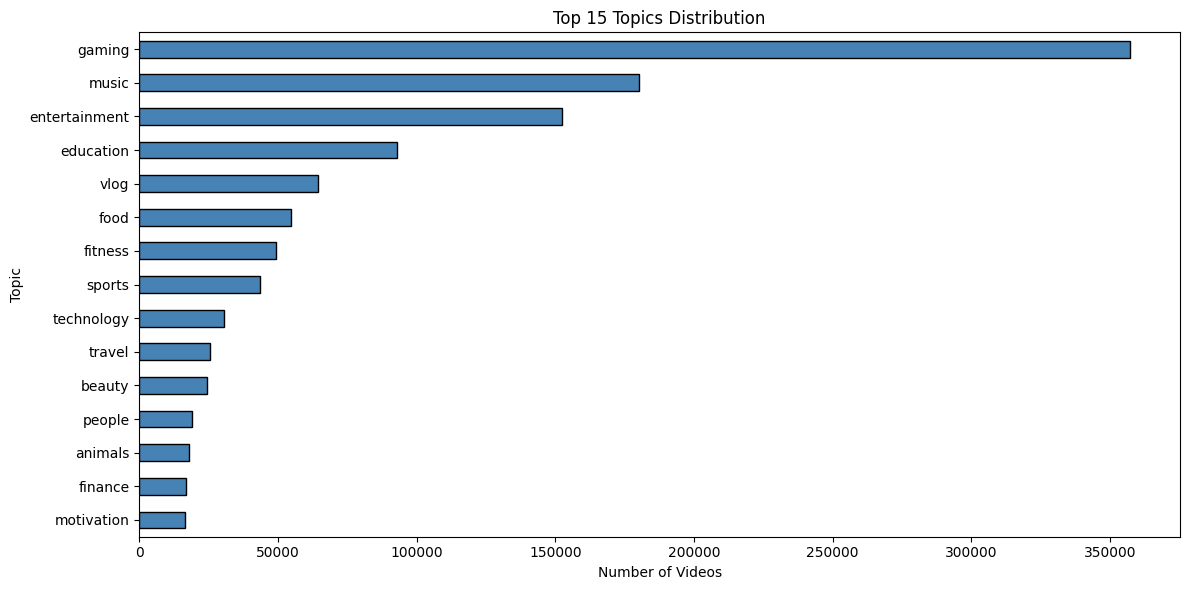

In [16]:
# Distribution plot
topic_counts = df_video['topic'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
topic_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Videos')
ax.set_ylabel('Topic')
ax.set_title('Top 15 Topics Distribution')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
# Topic vs Trending status
topic_trending = pd.crosstab(df_video['topic'], df_video['is_trending'], normalize='index') * 100
topic_trending.columns = ['Non-Trending %', 'Trending %']
topic_trending = topic_trending.sort_values('Trending %', ascending=False)

print("=== TOPIC vs TRENDING ===")
print(topic_trending)

=== TOPIC vs TRENDING ===
               Non-Trending %  Trending %
topic                                    
howto                0.000000  100.000000
news                 0.000000  100.000000
cars                 0.000000  100.000000
comedy               0.000000  100.000000
film                 0.000000  100.000000
science              0.000000  100.000000
pets                 0.000000  100.000000
people               0.000000  100.000000
nonprofit            0.000000  100.000000
gaming              52.906821   47.093179
music               62.276815   37.723185
entertainment       91.803472    8.196528
sports              98.283992    1.716008
travel              99.507466    0.492534
education           99.719403    0.280597
technology         100.000000    0.000000
animals            100.000000    0.000000
motivation         100.000000    0.000000
kids               100.000000    0.000000
beauty             100.000000    0.000000
food               100.000000    0.000000
fitness 

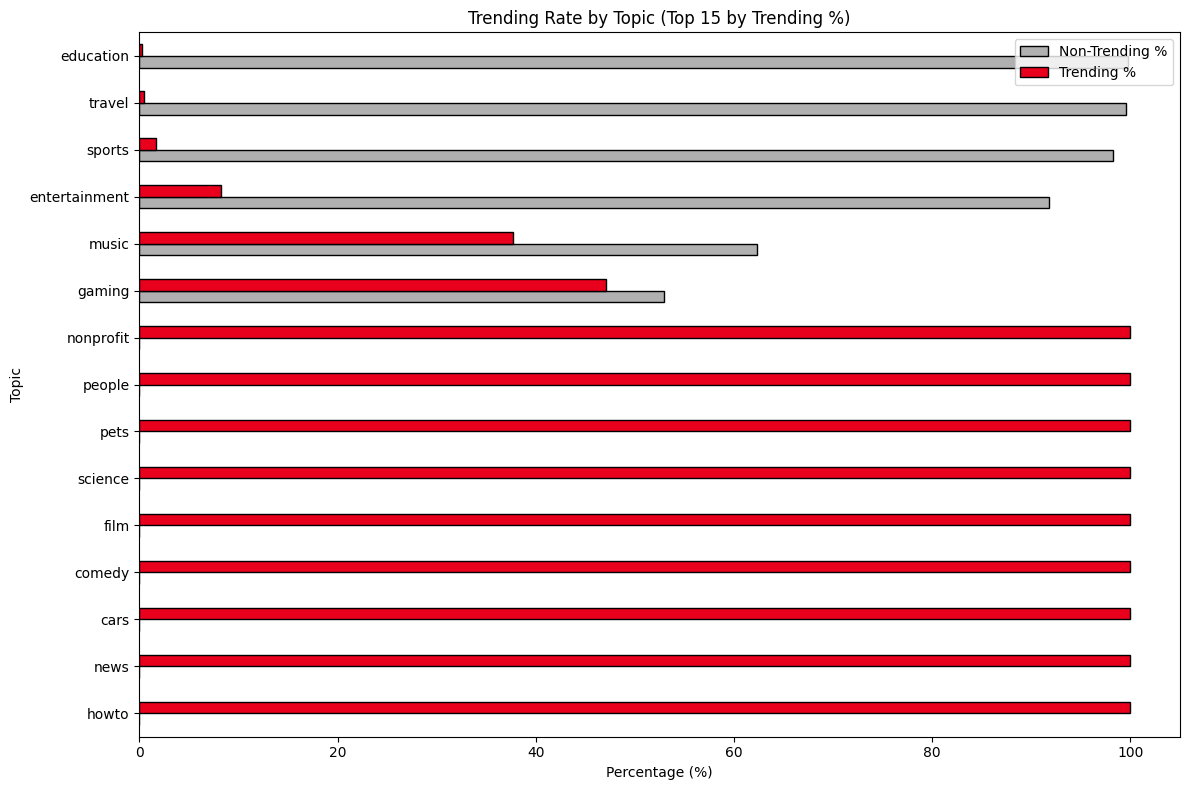

In [27]:
# Plot Topic Trending Rate (Top 15)
fig, ax = plt.subplots(figsize=(12, 8))
topic_trending.head(15).plot(kind='barh', ax=ax, color=['#B0B0B0', '#E8001D'], edgecolor='black')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Topic')
ax.set_title('Trending Rate by Topic (Top 15 by Trending %)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

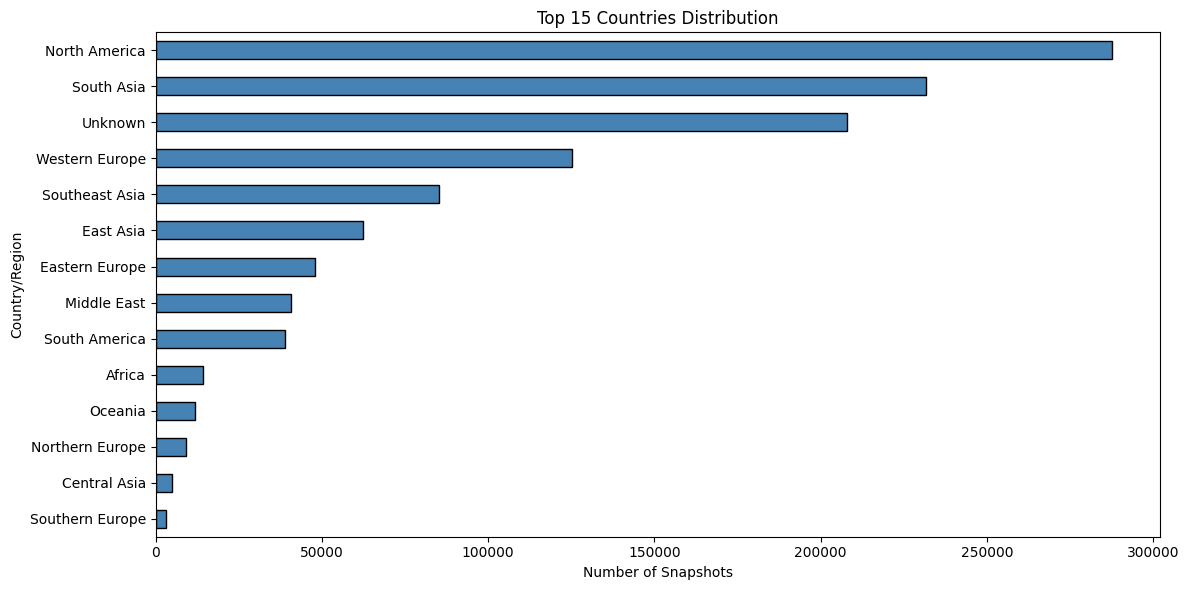

In [19]:
# Distribution plot
country_counts = df_video['country_region'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
country_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Snapshots')
ax.set_ylabel('Country/Region')
ax.set_title('Top 15 Countries Distribution')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

=== TOP 10 COUNTRIES BY TRENDING RATE ===
                 Non-Trending %  Trending %
country_region                             
Middle East           31.288721   68.711279
Eastern Europe        31.771758   68.228242
Central Asia          34.896958   65.103042
Southern Europe       40.699935   59.300065
South America         50.848198   49.151802
East Asia             53.885281   46.114719
Africa                56.855266   43.144734
Southeast Asia        64.078901   35.921099
Northern Europe       65.646552   34.353448
Western Europe        67.671038   32.328962


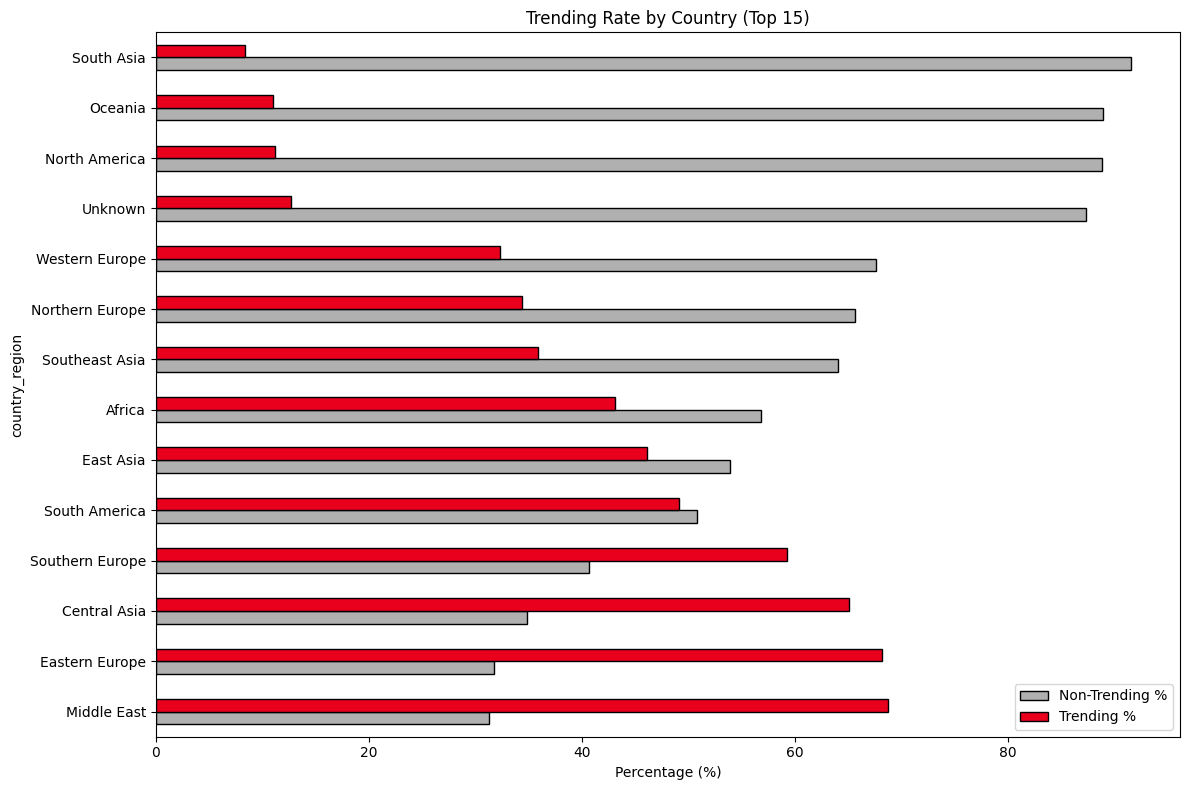

In [30]:
# Country vs Trending status
country_trending = pd.crosstab(df_video['country_region'], df_video['is_trending'], normalize='index') * 100
country_trending.columns = ['Non-Trending %', 'Trending %']
country_trending = country_trending.sort_values('Trending %', ascending=False)

print("=== TOP 10 COUNTRIES BY TRENDING RATE ===")
print(country_trending.head(10))

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
country_trending.head(15).plot(kind='barh', ax=ax, color=['#B0B0B0', '#E8001D'], edgecolor='black')
ax.set_xlabel('Percentage (%)')
ax.set_title('Trending Rate by Country (Top 15)')
plt.tight_layout()
plt.show()

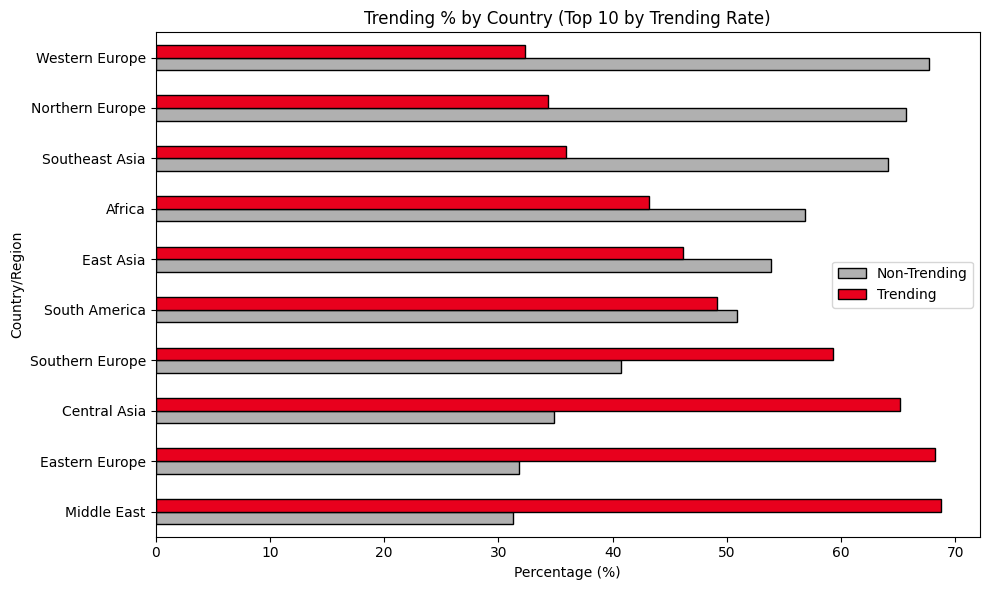

In [22]:
# Country vs Trending status - FIX
country_trending = pd.crosstab(df_video['country_region'], df_video['is_trending'], normalize='index') * 100
country_trending.columns = ['Non-Trending', 'Trending']  # Đặt tên cột rõ ràng
country_trending = country_trending.sort_values('Trending', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
country_trending.plot(kind='barh', ax=ax, color=['#B0B0B0', '#E8001D'], edgecolor='black')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Country/Region')
ax.set_title('Trending % by Country (Top 10 by Trending Rate)')
ax.legend(['Non-Trending', 'Trending'])
plt.tight_layout()
plt.show()

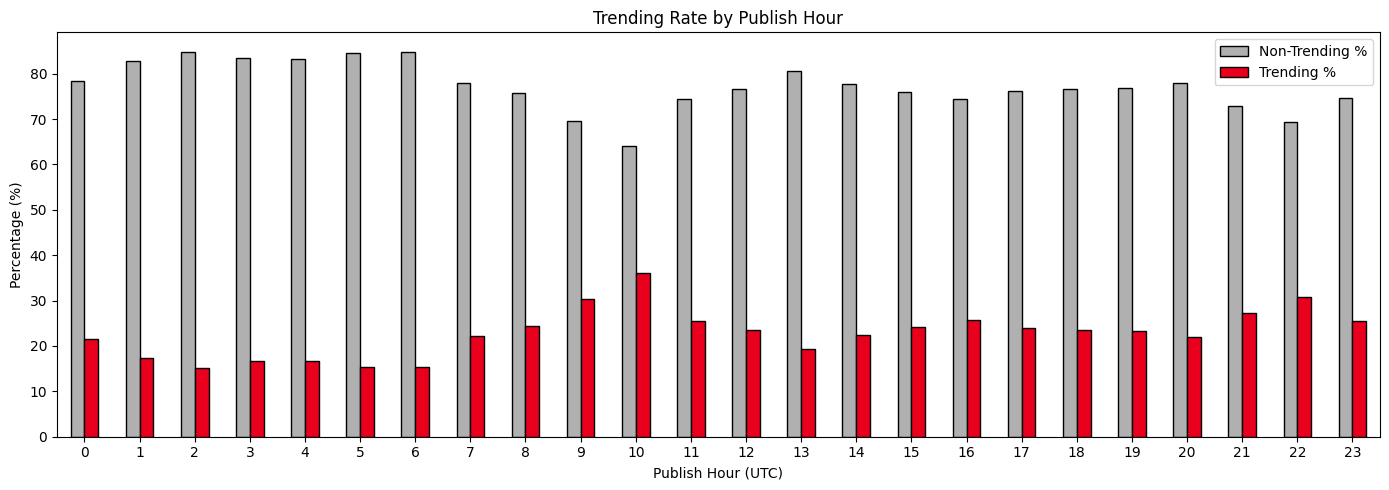

In [28]:
# Hour distribution
hour_trending = pd.crosstab(df_video['publish_hour'], df_video['is_trending'], normalize='index') * 100
hour_trending.columns = ['Non-Trending %', 'Trending %']

fig, ax = plt.subplots(figsize=(14, 5))
hour_trending.plot(kind='bar', ax=ax, color=['#B0B0B0', '#E8001D'], edgecolor='black')
ax.set_xlabel('Publish Hour (UTC)')
ax.set_ylabel('Percentage (%)')
ax.set_title('Trending Rate by Publish Hour')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

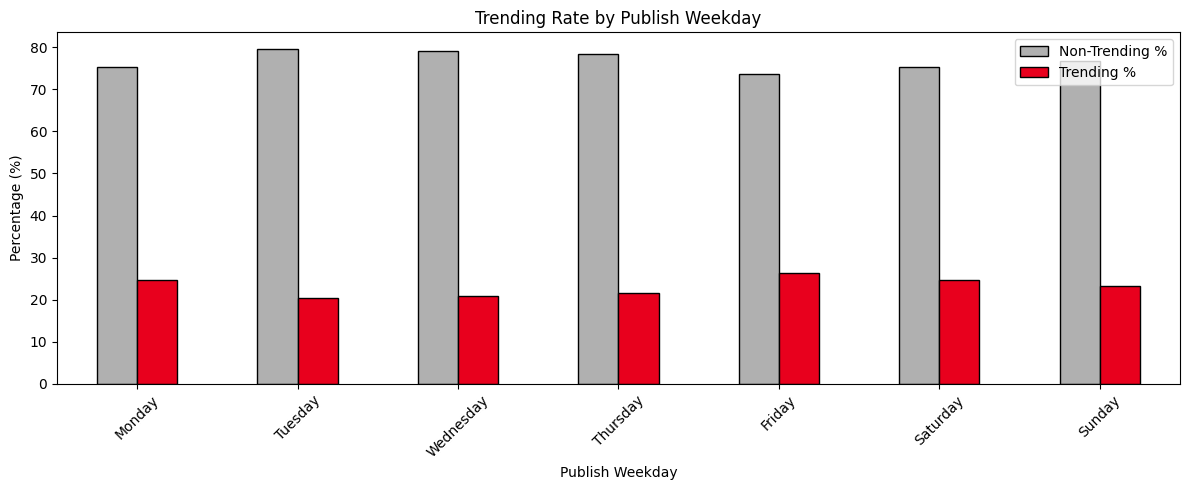

In [32]:
# Weekday distribution - SIMPLER FIX
weekday_trending = pd.crosstab(df_video['publish_weekday'], df_video['is_trending'], normalize='index') * 100
weekday_trending.columns = ['Non-Trending %', 'Trending %']
weekday_trending['day_name'] = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_trending = weekday_trending.set_index('day_name')

fig, ax = plt.subplots(figsize=(12, 5))
weekday_trending.plot(kind='bar', ax=ax, color=['#B0B0B0', '#E8001D'], edgecolor='black')
ax.set_xlabel('Publish Weekday')
ax.set_ylabel('Percentage (%)')
ax.set_title('Trending Rate by Publish Weekday')
ax.legend(loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

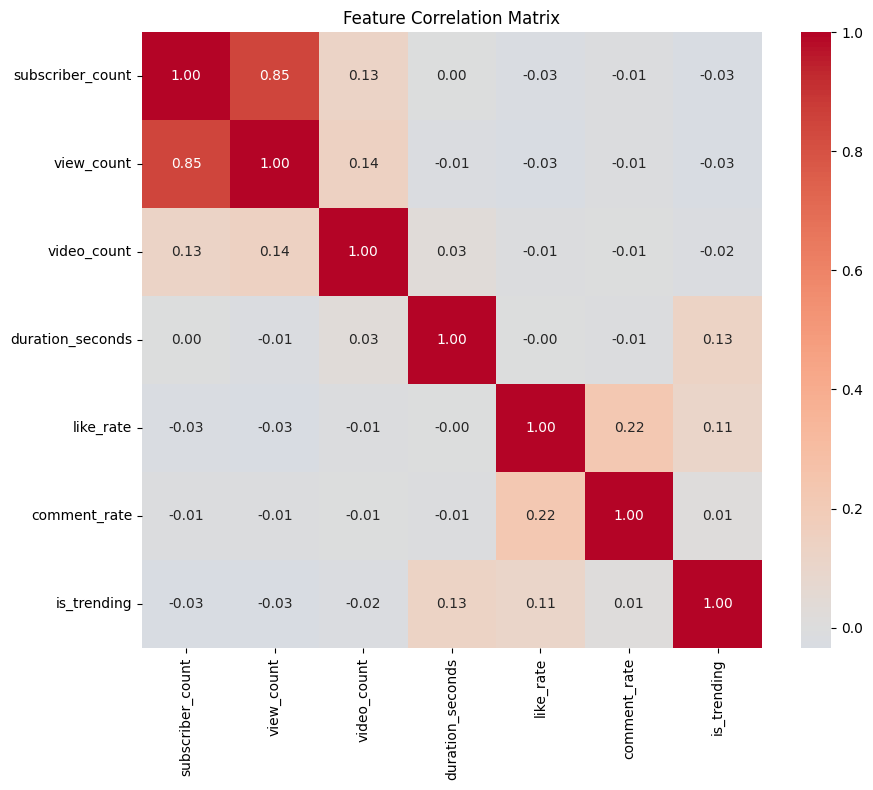

In [25]:
# Correlation Matrix
features_numeric = ['subscriber_count', 'view_count', 'video_count', 'duration_seconds', 
                     'like_rate', 'comment_rate', 'is_trending']
correlation_matrix = df_video[features_numeric].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()